In [56]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la
from scipy.optimize import minimize
from skimage.feature import peak_local_max

%matplotlib inline

### Question 01

In [57]:
im = cv.imread('a2images/the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
im_gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)

In [58]:
h, w = im_gray.shape
sigmas = np.arange(1,11,1)

scale_space = np.empty((h, w, len(sigmas)), dtype=np.float32)
for i, sigma in enumerate(sigmas):
    log_hw = 3 * sigma
    X, Y = np.meshgrid(np.arange(-log_hw, log_hw + 1, 1), np.arange(-log_hw, log_hw + 1, 1))
    log = 1/(2*np.pi*sigma**2)*(X**2/(sigma**2) + Y**2/(sigma**2) - 2)*np.exp(-(X**2 + Y**2)/(2*sigma**2))
    f_log = cv.filter2D(im_gray, -1, log)
    scale_space[:, :, i] = f_log
local_maxima_coords = peak_local_max(scale_space, footprint=np.ones((3, 3, len(sigmas))), threshold_rel=0.7)

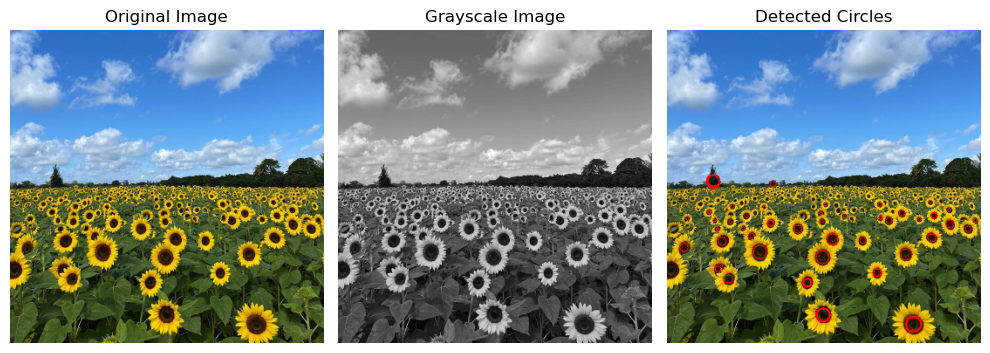

Max radius is: 9
Max circle in: (282, 337)


In [60]:
# plot circles on original image
max_radius = 0
max_cood = tuple()
im_with_circles = im_rgb.copy()
for coord in local_maxima_coords:
    y, x, sigma_idx = coord
    sigma = sigmas[sigma_idx]
    radius = int(np.sqrt(2) * sigma)
    if radius > max_radius:
        max_radius = radius
        max_cood = (x, y)
    cv.circle(im_with_circles, (x, y), radius, (255, 0, 0), 1)
    
# Plot the results
fig, axs = plt.subplots(1, 3, figsize=(10, 10))
axs[0].imshow(im_rgb)
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(im_gray, cmap='gray')
axs[1].set_title('Grayscale Image')
axs[1].axis('off')
axs[2].imshow(im_with_circles)
axs[2].set_title('Detected Circles')
axs[2].axis('off')
plt.tight_layout()
plt.show()


print(f"Max radius is: {max_radius}")
print(f"Max circle in: {max_cood}")

### Question 02

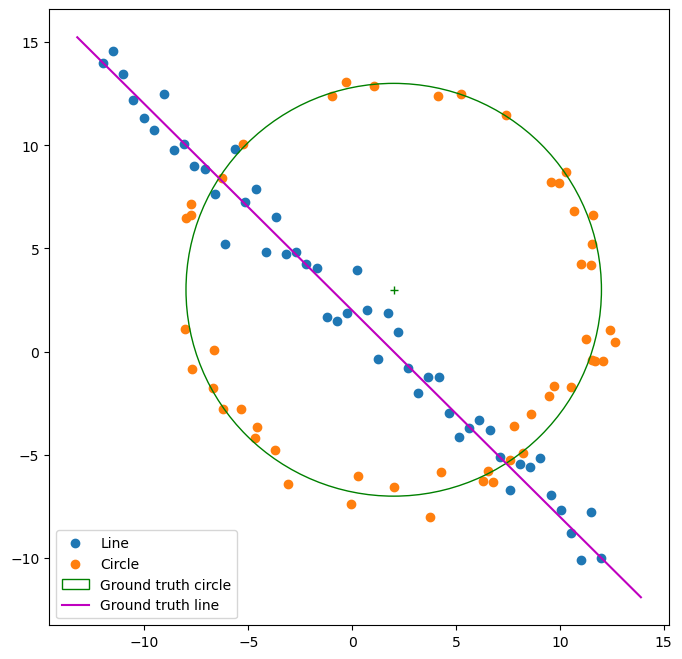

In [5]:
# Generation of a Noisy Point Set Conforming to a Line and a Circle
import numpy as np
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
import tikzplotlib

# np.random.seed(0)
N= 100
half_n =N//2
r = 10
x0_gt , y0_gt = 2, 3 # Center
s = r/16
t = np.random.uniform(0, 2*np.pi , half_n)
n = s*np.random.randn(half_n)
x, y = x0_gt + (r + n)*np.cos(t), y0_gt + (r + n)*np.sin(t)
X_circ = np.hstack((x.reshape(half_n ,1) , y.reshape(half_n ,1)))

s = 1.
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m*x + b + s*np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n ,1) , y.reshape(half_n ,1)))
X = np.vstack((X_circ , X_line )) # All points

fig , ax = plt.subplots(1,1, figsize =(8 ,8))

ax.scatter(X_line[:, 0], X_line[:, 1], label='Line')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle')
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)

ax.plot((x0_gt), (y0_gt), '+', color='g')
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m*x_ + b
plt.plot(x_, y_, color='m', label='Ground truth line')
plt.legend()

### RANSAC

In [6]:
def line_TLS(x, indices):
    a, b, d = x[0], x[1], x[2]
    return np.sum(np.square(a*X_line[indices, 0] + b*X_line[indices, 1] - d))

def circle_TLS(x, indices):
    x0, y0, r = x[0], x[1], x[2]
    return np.sum(np.square(np.sqrt((X_circ[indices, 0] - x0)**2 + (X_circ[indices, 1] - y0)**2) - r))

def cons(x):
    return x[0]**2 + x[1]**2 - 1
constr = {'type': 'eq', 'fun': cons}

def consensus_line(X, x, threshold):
    a, b, d = x[0], x[1], x[2]
    dists = np.abs(a*X[:, 0] + b*X[:, 1] - d)
    return dists < threshold

def consensus_circle(X, x, threshold):
    x0, y0, r = x[0], x[1], x[2]
    dists = np.abs(np.sqrt((X[:, 0] - x0)**2 + (X[:, 1] - y0)**2) - r)
    return dists < threshold



### RANSAC for Line

In [7]:
# Data and Parameters
X_line = X
N_line = X_line.shape[0]

# RANSAC for line fitting
threshold = 1.
dp = 0.35 * N_line # 35% of points needed to assert a good model
s = 2 # Minimum points to fit a model

max_iters = 1000
iterations = 0
inliers_line = []          # Line inliers
best_model_line = []       # RANSAC line
best_sample_line = []      # Best sample for line
best_error_line = np.inf
res_only_with_sample_line = []
best_inliers_line = []

for iterations in range(max_iters):
    indices = np.random.randint(0, N_line, s)
    x0 = np.array([1, 1, 0]) # Initial guess
    res = minimize(fun=line_TLS, x0=x0, args=indices, tol=1e-6, constraints=constr)
    if res.success:
        inliers_line = consensus_line(X_line, res.x, threshold)
        n_inliers = np.sum(inliers_line)

        if n_inliers > dp:
            
            x0 = res.x
            res = minimize(fun=line_TLS, x0=x0, args=inliers_line, tol=1e-6, constraints=constr)
            
            if res.fun < best_error_line:
                best_error_line = res.fun
                best_model_line = res.x
                best_sample_line = X_line[indices, :]
                best_inliers_line = inliers_line
                res_only_with_sample_line = x0

print("Best model for line (a, b, d):", best_model_line)


Best model for line (a, b, d): [0.68095133 0.73232871 1.75771423]


### RANSAC for Circle

In [8]:
# Data and Parameters
X_circ = X[~best_inliers_line]   # Remove the consensus of the best line
N_circ = X_circ.shape[0]

# RANSAC for circle fitting
threshold = 0.5
dp = 0.3 * N_circ   # 30% of points needed to assert a good model
s = 3               # Minimum points to fit a model

max_iters = 1000
iterations = 0
inliers_circ = []          # Circle inliers
best_model_circ = []       # RANSAC circle
best_sample_circ = []      # Best sample for circle
best_error_circ = np.inf
res_only_with_sample_circ = []
best_inliers_circ = []

while iterations < max_iters:
    indices = np.random.randint(0, N_circ, s)
    x0 = np.array([1, 1, 1])  # Initial guess
    res = minimize(fun=circle_TLS, x0=x0, args=indices, tol=1e-6)
    if res.success:
        inliers_circ = consensus_circle(X_circ, res.x, threshold)
        n_inliers = np.sum(inliers_circ)
      
        if n_inliers > dp:
            x0 = res.x
            res = minimize(fun=circle_TLS, x0=x0, args=inliers_circ, tol=1e-6)
            
            if res.fun < best_error_circ:
                best_error_circ = res.fun
                best_model_circ = res.x
                best_sample_circ = X_circ[indices, :]
                best_inliers_circ = inliers_circ
                res_only_with_sample_circ = x0
                
    iterations += 1

print("Best model for circle (a, b, r):", best_model_circ)


Best model for circle (a, b, r): [1.65341559 3.89342504 9.97407174]


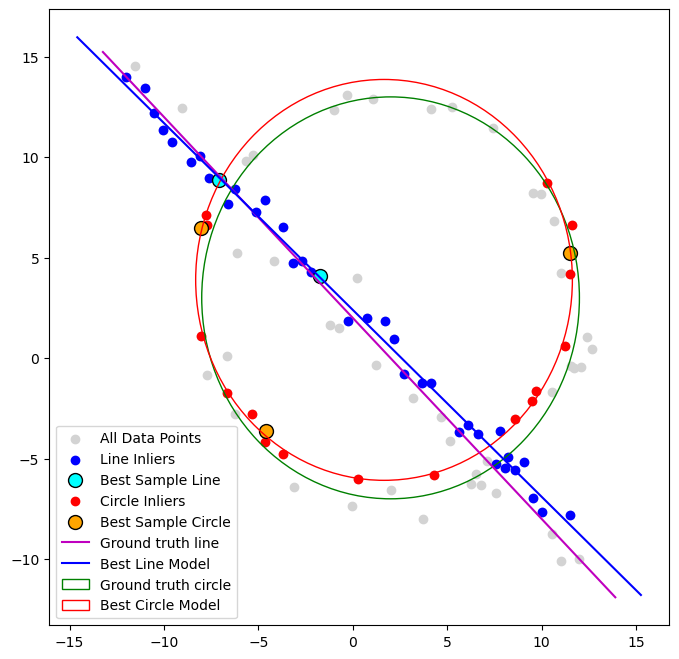

In [9]:
# Plotting the results
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# All data points
ax.scatter(X[:, 0], X[:, 1], label='All Data Points', color='lightgray')

# Line inliers
ax.scatter(X_line[best_inliers_line, 0], X_line[best_inliers_line, 1], label='Line Inliers', color='blue')
# Best sample for line
ax.scatter(best_sample_line[:, 0], best_sample_line[:, 1], label='Best Sample Line', color='cyan', edgecolor='black', s=100, marker='o')

# Circle inliers
ax.scatter(X_circ[best_inliers_circ, 0], X_circ[best_inliers_circ, 1], label='Circle Inliers', color='red')
# Best sample for circle
ax.scatter(best_sample_circ[:, 0], best_sample_circ[:, 1], label='Best Sample Circle', color='orange', edgecolor='black', s=100, marker='o')

# Plotting Ground Truth line
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m*x_ + b
plt.plot(x_, y_, color='m', label='Ground truth line')

# Plotting the best line model
x_vals = np.array(ax.get_xlim())
m = (-best_model_line[0]/best_model_line[1])
c = (best_model_line[2]/best_model_line[1])
y_vals = m * x_vals + c
ax.plot(x_vals, y_vals, color='blue', label='Best Line Model')

# Plotting Ground Truth circle
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)

# Plotting the best circle model
circle = plt.Circle((best_model_circ[0], best_model_circ[1]), best_model_circ[2], color='red', fill=False, label='Best Circle Model')
ax.add_artist(circle)

ax.legend()
plt.show()

## Question 03

In [10]:
logo_image = cv.imread('a2images/entc.png')
logo_image = cv.cvtColor(logo_image, cv.COLOR_BGR2RGB)
bill_image = cv.imread('a2images/bill_board.jpg')
bill_image = cv.cvtColor(bill_image, cv.COLOR_BGR2RGB)

sanga_image = cv.imread('a2images/sanga.jpg')
sanga_image = cv.cvtColor(sanga_image, cv.COLOR_BGR2RGB)
book_image = cv.imread('a2images/book.jpg')
book_image = cv.cvtColor(book_image, cv.COLOR_BGR2RGB)

In [12]:
import cv2

# Store the clicked points in a list
clicked_points = []

# Mouse callback function to get coordinates
def get_point(event, x, y, flags, param):
    """Callback function to record the coordinates of mouse clicks."""
    if event == cv2.EVENT_LBUTTONDOWN:
        clicked_points.append((x, y))
        print(f"Point recorded: ({x}, {y})")

        # Draw a small circle to visualize the clicked point
        cv2.circle(image, (x, y), 5, (0, 255, 0), -1)
        cv2.imshow("Image", image)

# Load the image
image = bill_image.copy()

if image is None:
    print(f"Error: Could not read image at {image_path}")
else:
    # Create a window to display the image
    cv2.namedWindow("Image")

    # Set the mouse callback function for the window
    cv2.setMouseCallback("Image", get_point)

    # Display the image and wait for mouse clicks
    cv2.imshow("Image", image)

    print("Click on the image to select points. Press 'q' to quit.")

    # Loop until 'q' is pressed
    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break

    # Clean up and close windows
    cv2.destroyAllWindows()

    # Print the final list of points
    print("\nAll captured points:")
    print(clicked_points)



Click on the image to select points. Press 'q' to quit.
Point recorded: (446, 285)
Point recorded: (1362, 113)
Point recorded: (1357, 671)
Point recorded: (436, 735)

All captured points:
[(446, 285), (1362, 113), (1357, 671), (436, 735)]


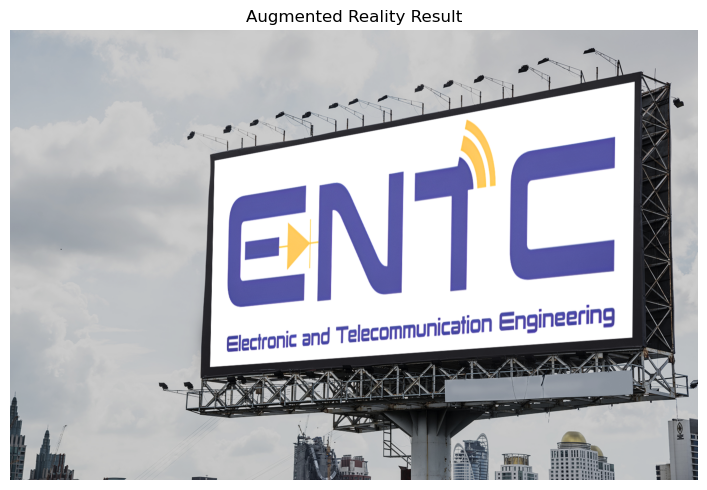

In [13]:
pts_building = np.array(clicked_points, dtype=np.float32) # Clicked points
pts_flag = np.array([[0, 0], [logo_image.shape[1], 0], [logo_image.shape[1],
                    logo_image.shape[0]], [0, logo_image.shape[0]]], dtype=np.float32)

H,_= cv2.findHomography(pts_flag, pts_building) # Homography matrix
warped_flag = cv2.warpPerspective(logo_image, H,(bill_image.shape[1], bill_image.shape[0])) # Warp 2nd image

mask = np.zeros_like(bill_image, dtype=np.uint8) # Mask for overlay image
cv2.fillConvexPoly(mask, pts_building.astype(int), (255, 255, 255))
# Blend the warped flag with the building image
blended = cv2.addWeighted(bill_image, 0.8, warped_flag, 0.9, 0)

plt.figure(figsize=(10,5))
plt.imshow(blended)
plt.axis('off')
plt.title('Augmented Reality Result')
plt.tight_layout()
plt.show()

In [14]:
import cv2
import numpy as np

# Store the clicked points in a list
clicked_points = []

# Mouse callback function to get coordinates
def get_point(event, x, y, flags, param):
    """Callback function to record the coordinates of mouse clicks."""
    if event == cv2.EVENT_LBUTTONDOWN:
        clicked_points.append([x, y])
        print(f"Point recorded: ({x}, {y})")

        # Draw a small circle to visualize the clicked point
        cv2.circle(image, (x, y), 5, (0, 255, 0), -1)
        cv2.imshow("Image", image)

# Load the image
image = book_image.copy()

if image is None:
    print(f"Error: Could not read image at {image_path}")
else:
    # Create a window to display the image
    cv2.namedWindow("Image")

    # Set the mouse callback function for the window
    cv2.setMouseCallback("Image", get_point)

    # Display the image and wait for mouse clicks
    cv2.imshow("Image", image)

    print("Click on the image to select points. Press 'q' to quit.")

    # Loop until 'q' is pressed
    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break

    # Clean up and close windows
    cv2.destroyAllWindows()

    # Print the final list of points
    print("\nAll captured points:")
    print(clicked_points)



Click on the image to select points. Press 'q' to quit.
Point recorded: (459, 133)
Point recorded: (686, 175)
Point recorded: (552, 475)
Point recorded: (271, 403)

All captured points:
[[459, 133], [686, 175], [552, 475], [271, 403]]


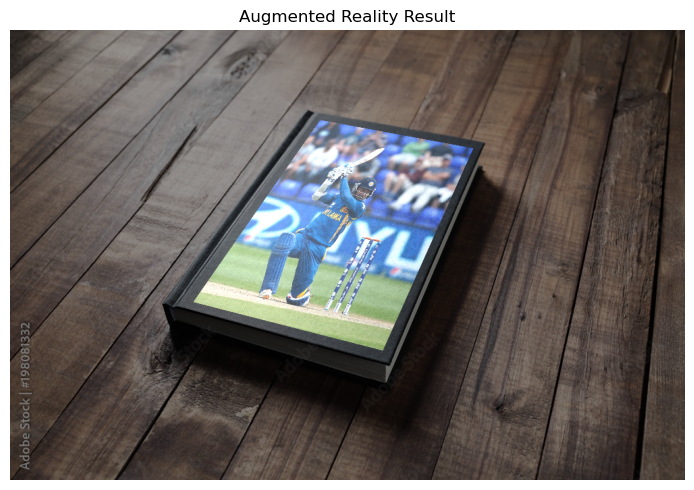

In [16]:
pts_building = np.array(clicked_points, dtype=np.float32) # Clicked points
pts_flag = np.array([[0, 0], [sanga_image.shape[1], 0], [sanga_image.shape[1],
                    sanga_image.shape[0]], [0, sanga_image.shape[0]]], dtype=np.float32)

H,_= cv2.findHomography(pts_flag, pts_building) # Homography matrix
warped_flag = cv2.warpPerspective(sanga_image, H,(book_image.shape[1], book_image.shape[0])) # Warp 2nd image

mask = np.zeros_like(book_image, dtype=np.uint8) # Mask for overlay image
cv2.fillConvexPoly(mask, pts_building.astype(int), (255, 255, 255))
# Blend the warped flag with the building image
blended = cv2.addWeighted(book_image, .6, warped_flag, 0.9, 0)

plt.figure(figsize=(10,5))
plt.imshow(blended)
plt.axis('off')
plt.title('Augmented Reality Result')
plt.tight_layout()
plt.show()

### Question 04

In [28]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from skimage import transform

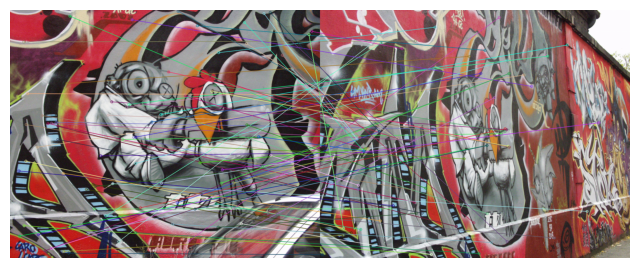

In [43]:
img1 = cv.imread('graf\img1.ppm', cv.IMREAD_COLOR)
img2 = cv.imread('graf\img5.ppm', cv.IMREAD_COLOR)

img1_gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)
img2_gray = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)

# Create SIFT detector object
sift = cv.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(img1_gray, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2_gray, None)

# Use BFMatcher to find the best matches
bf = cv.BFMatcher()
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Apply ratio test to filter good matches
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# Draw matches
img_matches = cv.drawMatches(img1, keypoints1, img2, keypoints2, good_matches, None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(8,8))
plt.imshow(cv.cvtColor(img_matches, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [53]:
# Collect all matching points
src_pts, dst_pts = [], []

for match in good_matches:
    src_pts.append(np.array(keypoints1[match.queryIdx].pt))
    dst_pts.append(np.array(keypoints2[match.trainIdx].pt))

src_pts = np.array(src_pts)
dst_pts = np.array(dst_pts)

# RANSAC for finding best homography
num_points = 4
thres = 1
d = 0.5 * len(good_matches)
iters = 200

best_homography = None
best_inlier_count = 0
best_inliers = None

for i in range(iters):
    # Randomly choose matches
    chosen_matches = np.random.choice(good_matches, num_points, replace=False)

    # Extract corresponding source and destination points
    sample_src_pts = np.array([np.array(keypoints1[m.queryIdx].pt) for m in chosen_matches])
    sample_dst_pts = np.array([np.array(keypoints2[m.trainIdx].pt) for m in chosen_matches])

    # Estimate projective transform (homography)
    tform = transform.estimate_transform('projective', sample_src_pts, sample_dst_pts)

    # Compute errors between transformed and actual destination points
    projected_pts = tform(src_pts)
    errors = np.sqrt(np.sum(np.square(projected_pts - dst_pts), axis=1))

    # Identify inliers
    inliers = np.where(errors < thres)[0]

    # Keep best homography
    if len(inliers) > best_inlier_count:
        best_inlier_count = len(inliers)
        best_homography = tform
        best_inliers = inliers

print(f'Best no. of inliers = {best_inlier_count}')

Best no. of inliers = 6


In [54]:
print("Best Homography Matrix:")
print(best_homography.params)

Best Homography Matrix:
[[-1.69342151e-02 -4.96219888e-01  1.61582356e+02]
 [-1.77141748e-01 -1.17170997e+00  3.90118397e+02]
 [-3.03418907e-04 -3.10987565e-03  1.00000000e+00]]


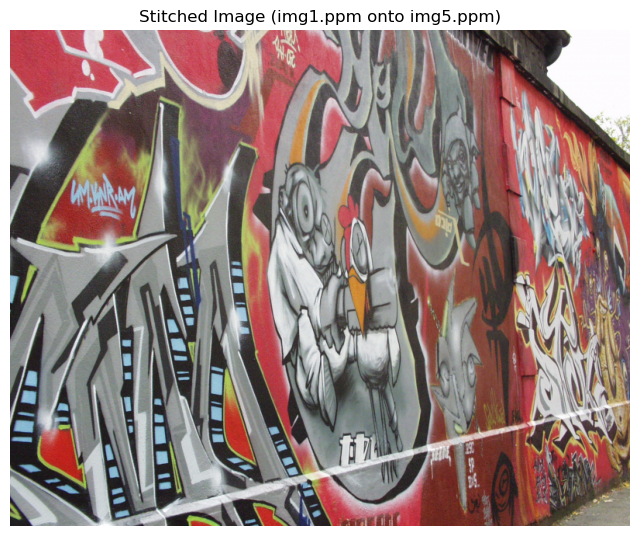

In [55]:
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

corners = np.float32([[0,0], [0,h1], [w1,h1], [w1,0]]).reshape(-1,1,2)
warped_corners = cv2.perspectiveTransform(corners, best_homography.params)
combined_corners = np.concatenate((warped_corners, np.float32([[0,0],[0,h2],[w2,h2],[w2,0]]).reshape(-1,1,2)), axis=0)

[x_min, y_min] = np.int32(combined_corners.min(axis=0).ravel() - 0.5)
[x_max, y_max] = np.int32(combined_corners.max(axis=0).ravel() + 0.5)
translation = [-x_min, -y_min]
H_translate = np.array([[1, 0, translation[0]], [0, 1, translation[1]], [0, 0, 1]])

stitched = cv2.warpPerspective(img1, H_translate @ best_homography, (x_max - x_min, y_max - y_min))
stitched[translation[1]:h2+translation[1], translation[0]:w2+translation[0]] = img2

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(stitched, cv2.COLOR_BGR2RGB))
plt.title("Stitched Image (img1.ppm onto img5.ppm)")
plt.axis("off")
plt.show()